<a href="https://colab.research.google.com/github/sandeepa-ukr/AI-Based-Crop-Predection/blob/main/crop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ML imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
crop_files = [
    ("apples.csv", "apples"),
    ("apricots.csv", "apricots"),
    ("areca_nuts.csv", "areca nuts"),
    ("bananas.csv", "bananas"),
    ("barley.csv", "barley"),
    ("beans_dry.csv", "beans dry"),
    ("beans_green.csv", "beans green"),
    ("cabbage.csv", "cabbage"),
    ("carrots.csv", "carrots"),
    ("cashewnuts.csv", "cashewnuts"),
    ("cauliflower.csv", "cauliflower"),
    ("cherries.csv", "cherries"),
    ("chilli_dry.csv", "chilli dry"),
    ("chilli_green.csv", "chilli green"),
    ("coconuts.csv", "coconuts"),
    ("coffee.csv", "coffee"),
    ("cucumber.csv", "cucumber"),
    ("eggplant.csv", "eggplant"),
    ("fennel_coriander.csv", "fennel coriander"),
    ("garlic.csv", "garlic"),
    ("ginger.csv", "ginger"),
    ("grapes.csv", "grapes"),
    ("groundnuts.csv", "groundnuts"),
    ("lemons.csv", "lemons"),
    ("lentils.csv", "lentils"),
    ("lettuce.csv", "lettuce"),
    ("maize.csv", "maize"),
    ("mangoes.csv", "mangoes"),
    ("melons.csv", "melons"),
    ("nutmeg.csv", "nutmeg"),
    ("okra.csv", "okra"),
    ("onions.csv", "onions"),
    ("oranges.csv", "oranges"),
    ("papaya.csv", "papaya"),
    ("peaches.csv", "peaches"),
    ("pears.csv", "pears"),
    ("peas.csv", "peas"),
    ("pepper.csv", "pepper"),
    ("pineapples.csv", "pineapples"),
    ("potatoes.csv", "potatoes"),
    ("pumpkins.csv", "pumpkins"),
    ("rice.csv", "rice"),
    ("safflower.csv", "safflower"),
    ("sesame.csv", "sesame"),
    ("soyabean.csv", "soyabean"),
    ("sugarcane.csv", "sugarcane"),
    ("tomatoes.csv", "tomatoes"),
    ("watermelon.csv", "watermelon"),
    ("wheat.csv", "wheat"),
]

In [3]:
crop_dfs = []
for fname, crop_name in crop_files:
    tmp = pd.read_csv(fname)
    # tmp = tmp.copy()
    # tmp['Year'] = tmp['Year'].astype(int)
    # tmp['crop_type'] = crop_name
    tmp = pd.read_csv(fname)
    tmp['crop_type'] = crop_name
    crop_dfs.append(tmp)

crop_df = pd.concat(crop_dfs, ignore_index=True, axis=0)
print(f"Loaded crop_df shape: {crop_df.shape}")

Loaded crop_df shape: (8526, 18)


In [4]:
# Keep only Yield rows (FAOSTAT typically also has 'Area harvested' and 'Production' as Elements)
print("Elements before filtering:", crop_df['Element'].unique())

crop_df = crop_df[crop_df['Element'].str.contains('Yield', case=False, na=False)]

print("Crop data shape after keeping only Yield rows:", crop_df.shape)
print("Elements after filtering:", crop_df['Element'].unique())

Elements before filtering: ['Area harvested' 'Yield' 'Production']
Crop data shape after keeping only Yield rows: (2842, 18)
Elements after filtering: ['Yield']


In [5]:
# Check for basic data quality
print("\n=== Data Quality Checks ===")
print(f"Total rows: {len(crop_df)}")
print(f"Null values per column:")
print(crop_df.isnull().sum())
print(f"\nDataFrame info:")
print(crop_df.info())

# Check unique values in key columns
print(f"\nUnique crops: {crop_df['Item'].nunique() if 'Item' in crop_df.columns else 'Item column not found'}")
print(f"Year range: {crop_df['Year'].min() if 'Year' in crop_df.columns else 'Year column not found'} - {crop_df['Year'].max() if 'Year' in crop_df.columns else 'Year column not found'}")


=== Data Quality Checks ===
Total rows: 2842
Null values per column:
Domain Code             0
Domain                  0
Area Code (FAO)         0
Area                    0
Element Code            0
Element                 0
Item Code (FAO)         0
Item                    0
Year Code               0
Year                    0
Unit                    0
Value                   0
Flag                    0
Flag Description        0
Nitrogen (N) kg/ha      0
Phosphorus (P) kg/ha    0
Potassium (K) kg/ha     0
crop_type               0
dtype: int64

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 2842 entries, 58 to 8467
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Domain Code           2842 non-null   object 
 1   Domain                2842 non-null   object 
 2   Area Code (FAO)       2842 non-null   int64  
 3   Area                  2842 non-null   object 
 4   Element Code      

In [6]:
rainfall = pd.read_csv('rainfall.csv')
temperature = pd.read_csv('temperature.csv')

In [7]:
for dfc in (rainfall, temperature):
    if 'YEAR' in dfc.columns:
        dfc.rename(columns={'YEAR': 'Year'}, inplace=True)
    if 'Year' not in dfc.columns:
        raise ValueError("Climate files must have a 'Year' column")

In [8]:

climate_df = pd.merge(rainfall, temperature, on='Year', how='outer')
merged_df = pd.merge(climate_df, crop_df, on='Year', how='outer')

# Or in one line
# merged_df = pd.merge(pd.merge(df1, df2, on='Year', how='outer'), df3, on='Year', how='outer')

In [9]:
# compute seasonal aggregates if not present
if 'winter_avg' not in climate_df.columns:
    # winter defined here as DEC (prev), JAN, FEB — approximation using available DEC/JAN/FEB
    # Because DEC previous-year isn't directly available per-row, we compute seasonal proxies as mean of DJF where available
    climate_df['winter_avg'] = climate_df[['DEC', 'JAN', 'FEB']].mean(axis=1)
if 'summer_avg' not in climate_df.columns:
    climate_df['summer_avg'] = climate_df[['MAR', 'APR', 'MAY']].mean(axis=1)
if 'monsoon_avg' not in climate_df.columns:
    climate_df['monsoon_avg'] = climate_df[['JUN', 'JUL', 'AUG', 'SEP']].mean(axis=1)

climate_df['climate_std'] = climate_df[['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']].std(axis=1)

print("Climate preprocessing done.")

Climate preprocessing done.


In [10]:
climate_df.drop('ANN', axis=1, inplace=True)

In [11]:
# Display climate data info
print("Climate Data Info:")
print(climate_df.info())
print("\nFirst 5 rows of climate data:")
print(climate_df.head())

# Check for missing values
print("\nMissing values in climate data:")
print(climate_df.isnull().sum())

# Handle missing values if any
climate_df_clean = climate_df.copy()
for col in climate_df_clean.columns:
    if climate_df_clean[col].dtype in ['float64', 'int64']:
        climate_df_clean[col] = climate_df_clean[col].fillna(climate_df_clean[col].mean())

# Ensure Year column is integer
climate_df_clean['Year'] = climate_df_clean['Year'].astype(int)

print(f"\nCleaned climate data shape: {climate_df_clean.shape}")

Climate Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         58 non-null     int64  
 1   JAN          58 non-null     float64
 2   FEB          58 non-null     float64
 3   MAR          58 non-null     float64
 4   APR          58 non-null     float64
 5   MAY          58 non-null     float64
 6   JUN          58 non-null     float64
 7   JUL          58 non-null     float64
 8   AUG          58 non-null     float64
 9   SEP          58 non-null     float64
 10  OCT          58 non-null     float64
 11  NOV          58 non-null     float64
 12  DEC          58 non-null     float64
 13  Jan-Feb      58 non-null     float64
 14  Mar-May      58 non-null     float64
 15  Jun-Sep      58 non-null     float64
 16  Oct-Dec      58 non-null     float64
 17  ANNUAL       58 non-null     float64
 18  JAN-FEB      58 non-null     floa

In [12]:
climate_df_clean = climate_df_clean.drop(
    columns=['Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']
)

In [13]:
climate_df_clean

,Year,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,...,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC,winter_avg,summer_avg,monsoon_avg,climate_std
0,1961,26.1,34.8,26.0,28.5,77.6,192.9,336.6,287.6,234.9,...,10.4,24.00,18.98,26.11,27.06,21.17,23.766667,44.033333,263.000,116.831600
1,1962,12.6,21.6,16.0,43.6,70.8,137.1,281.6,276.9,211.0,...,29.9,24.04,18.91,25.91,27.14,21.47,21.366667,43.466667,226.650,102.202809
2,1963,6.8,9.8,41.7,50.6,60.9,168.0,258.6,316.7,164.9,...,15.5,24.15,19.07,25.57,27.21,22.04,10.700000,51.066667,227.050,103.295723
3,1964,18.6,14.1,19.0,40.0,52.1,177.2,345.7,273.7,200.4,...,13.3,24.10,18.83,26.38,26.90,21.58,15.333333,37.033333,249.250,115.764773
4,1965,11.8,28.1,26.7,45.1,52.7,116.1,270.1,192.8,129.5,...,22.2,24.07,19.22,25.24,27.08,22.10,20.700000,41.500000,177.125,82.034909
5,1966,13.1,25.4,20.3,30.6,57.2,178.8,252.5,212.5,143.9,...,16.7,24.36,19.93,26.07,27.17,21.83,18.400000,36.033333,196.925,85.149784
6,1967,11.1,14.2,63.3,29.5,42.8,144.0,305.6,264.3,170.3,...,56.1,24.11,19.44,25.55,27.19,21.68,27.133333,45.200000,221.050,101.803130
7,1968,29.4,19.8,27.5,32.6,46.7,149.6,309.9,212.8,129.5,...,12.6,23.94,18.25,25.62,27.22,21.69,20.600000,35.600000,200.450,94.076981
8,1969,12.7,14.5,20.1,39.7,63.4,130.2,317.8,273.4,172.7,...,12.7,24.46,19.18,26.39,27.35,22.20,13.300000,41.066667,223.525,105.974065
9,1970,23.2,27.3,25.9,29.2,69.7,215.9,245.6,313.0,212.7,...,1.6,24.26,19.56,26.39,27.06,21.55,17.366667,41.600000,246.800,109.732596


#Correlation-Based Feature Selection


Number of climate features: 20
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']


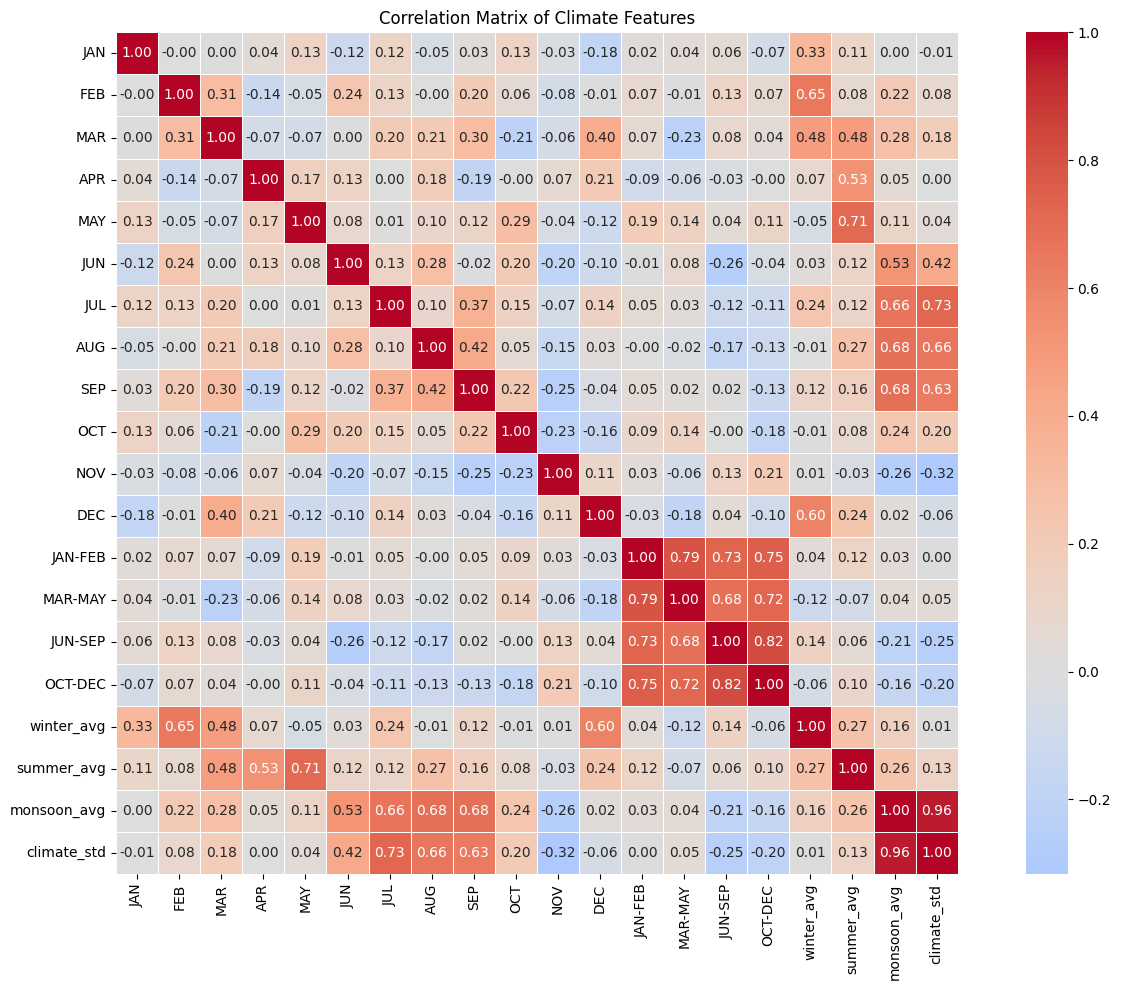


Highly correlated feature pairs (|corr| > 0.85):
     Feature 1    Feature 2  Correlation
0  monsoon_avg  climate_std     0.958369


In [14]:
# Separate features (exclude Year and any non-numeric columns)
feature_cols = [col for col in climate_df_clean.columns if col not in ['Year', 'ANNUAL']]
# Remove ANNUAL as it's already aggregated from other columns
feature_cols = [col for col in feature_cols if col != 'ANNUAL']

print(f"\nNumber of climate features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Correlation matrix
corr_matrix = climate_df_clean[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Climate Features')
plt.tight_layout()
plt.show()

# Identify highly correlated features (correlation > 0.85 or < -0.85)
threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\nHighly correlated feature pairs (|corr| > {threshold}):")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string())
else:
    print("No highly correlated pairs found.")

In [15]:
# Strategy: Keep the feature with higher variance or better interpretability
def handle_correlated_features(df, corr_threshold=0.85):
    """
    Remove highly correlated features, keeping the one with higher variance
    """
    # Calculate variance for each numeric feature
    variances = df.select_dtypes(include=[np.number]).var()

    # Get correlation matrix
    corr_matrix = df.select_dtypes(include=[np.number]).corr()

    # Find pairs with correlation above threshold
    features_to_drop = set()
    correlated_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > corr_threshold:
                feat1 = corr_matrix.columns[i]
                feat2 = corr_matrix.columns[j]
                correlated_pairs.append((feat1, feat2))

                # Keep the feature with higher variance
                if variances[feat1] >= variances[feat2]:
                    features_to_drop.add(feat2)
                else:
                    features_to_drop.add(feat1)

    return features_to_drop, correlated_pairs

In [16]:
# Apply the correlation handling
features_to_drop, correlated_pairs = handle_correlated_features(
    climate_df_clean,
    corr_threshold=0.85
)

print("\nFeatures to drop due to high correlation:")
print(features_to_drop)


Features to drop due to high correlation:
{'climate_std'}


In [17]:
# Create a clean dataset without these features
climate_reduced = climate_df_clean.drop(columns=features_to_drop, errors='ignore')

print(f"\nOriginal features: {len(climate_df_clean.columns)}")
print(f"Features after removing correlated: {len(climate_reduced.columns)}")
print(f"Remaining features: {climate_reduced.columns.tolist()}")


Original features: 22
Features after removing correlated: 21
Remaining features: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']


In [18]:
# ===================== 2. UPDATED FEATURE LIST =====================

# Get the remaining features (excluding Year and ANNUAL)
feature_cols = [col for col in climate_reduced.columns
                if col not in ['Year', 'ANNUAL']]

print(f"\nFeatures for analysis: {feature_cols}")
print(f"Number of features: {len(feature_cols)}")


Features for analysis: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']
Number of features: 19


In [19]:
# Load crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Element', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha' ]].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

print("\nCrop data:")
print(crop_data_clean.head())
print(f"Shape: {crop_data_clean.shape}")


Crop data:
    Year    Item Element  Value crop_type  Nitrogen (N) kg/ha  \
58  1965  Apples   Yield  41573    apples               46.33   
59  1966  Apples   Yield  41558    apples               85.55   
60  1967  Apples   Yield  41543    apples               94.41   
61  1968  Apples   Yield  41509    apples               77.99   
62  1969  Apples   Yield  41475    apples              156.02   

    Phosphorus (P) kg/ha  Potassium (K) kg/ha  
58                 50.38                45.03  
59                 44.48                10.98  
60                 23.67                91.48  
61                 60.57                18.22  
62                 29.65                38.74  
Shape: (2842, 8)


In [20]:
# F-score selected features (from your output)
# fscore_selected_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
# print(f"F-score selected features: {fscore_selected_features}")

# Load climate data with selected features
# climate_fscore = climate_df_clean[['Year'] + fscore_selected_features].copy()

climate_corr = climate_df_clean[['Year'] + feature_cols].copy()


print("\nClimate data with Correlation selected features:")
print(climate_corr.head())
print(f"Shape: {climate_corr.shape}")

# Load crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Element', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha' ]].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

print("\nCrop data:")
print(crop_data_clean.head())
print(f"Shape: {crop_data_clean.shape}")

# ===================== 2. MERGE CROP DATA WITH correlation selected FEATURES =====================

# Merge crop data with F-score selected climate features
merged_corr_data = pd.merge(
    crop_data_clean,
    climate_corr,
    on='Year',
    how='inner'
)

print("\nMerged dataset (crop + F-score selected features):")
print(merged_corr_data.head())
print(f"Shape: {merged_corr_data.shape}")
print(f"Columns: {merged_corr_data.columns.tolist()}")



Climate data with Correlation selected features:
   Year   JAN   FEB   MAR   APR   MAY    JUN    JUL    AUG    SEP    OCT  \
0  1961  26.1  34.8  26.0  28.5  77.6  192.9  336.6  287.6  234.9  122.2   
1  1962  12.6  21.6  16.0  43.6  70.8  137.1  281.6  276.9  211.0   78.4   
2  1963   6.8   9.8  41.7  50.6  60.9  168.0  258.6  316.7  164.9   99.1   
3  1964  18.6  14.1  19.0  40.0  52.1  177.2  345.7  273.7  200.4   67.4   
4  1965  11.8  28.1  26.7  45.1  52.7  116.1  270.1  192.8  129.5   34.0   

    NOV   DEC  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  winter_avg  summer_avg  \
0  21.7  10.4    18.98    26.11    27.06    21.17   23.766667   44.033333   
1  18.3  29.9    18.91    25.91    27.14    21.47   21.366667   43.466667   
2  28.4  15.5    19.07    25.57    27.21    22.04   10.700000   51.066667   
3  22.8  13.3    18.83    26.38    26.90    21.58   15.333333   37.033333   
4  18.2  22.2    19.22    25.24    27.08    22.10   20.700000   41.500000   

   monsoon_avg  
0      263.00

In [21]:
# ===================== 3. SAVE MERGED DATASET =====================

# Save the merged dataset
merged_corr_data.to_csv('crop_corr_merged_data.csv', index=False)
print("\n✅ Merged dataset saved to 'crop_corr_merged_data.csv'")


✅ Merged dataset saved to 'crop_corr_merged_data.csv'


##Cluster analyses

In [22]:
# ===================== 1. LOAD MERGED DATASET =====================

# Load the merged dataset (crop + correlation features)
merged_data = pd.read_csv('crop_corr_merged_data.csv')

print("="*60)
print("LOADED MERGED DATASET")
print("="*60)
print(f"Dataset shape: {merged_data.shape}")
print(f"Columns: {merged_data.columns.tolist()}")
print("\nFirst 5 rows:")
# print(merged_data.head())

# ===================== 2. PREPARE DATA FOR CLUSTERING =====================

# Select features for clustering (F-score selected features)
# fscore_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
# feature_cols= ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC']
print(f"\nFeatures used for clustering: {feature_cols}")

# Extract feature matrix
X = merged_data[feature_cols].copy()

# Handle missing values
X = X.fillna(X.mean())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"\nFeature matrix shape: {X_scaled_df.shape}")
print("Feature statistics after scaling:")
print(X_scaled_df.describe())

LOADED MERGED DATASET
Dataset shape: (2646, 27)
Columns: ['Year', 'Item', 'Element', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']

First 5 rows:

Features used for clustering: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']

Feature matrix shape: (2646, 19)
Feature statistics after scaling:
                JAN           FEB           MAR           APR           MAY  \
count  2.646000e+03  2.646000e+03  2.646000e+03  2.646000e+03  2.646000e+03   
mean  -4.682573e-16  4.494599e-16 -2.010653e-16  1.805896e-16 -1.779042e-17   
std    1.000189e+00  1.000189e+00  1.000189e+00  1.000189e+00  1.000189e+00   
min   -2.454380e+00 -1.643516e+00 -1.735011e+00 -1.


DETERMINING OPTIMAL NUMBER OF CLUSTERS


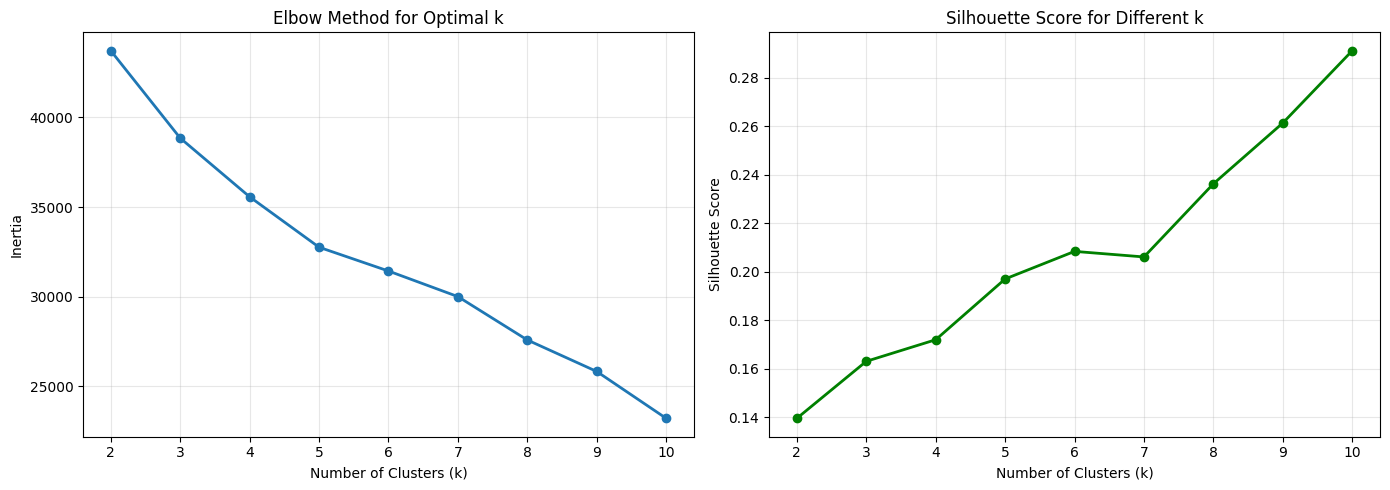

In [23]:
# ===================== 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD) =====================

print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

# Elbow method
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='o', color='green', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



#F-Score analyses

=== F-Score Analysis on Climate Data Only ===
Climate data shape: (58, 19)
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']

=== F-Score Results ===
        Feature    F_Score
12      JAN-FEB  24.958914
18  monsoon_avg  22.402208
14      JUN-SEP  17.807018
15      OCT-DEC  17.579121
17   summer_avg  16.923437
13      MAR-MAY  16.267823
16   winter_avg  15.485474
3           APR  12.570868
11          DEC  12.165149
4           MAY  11.952679


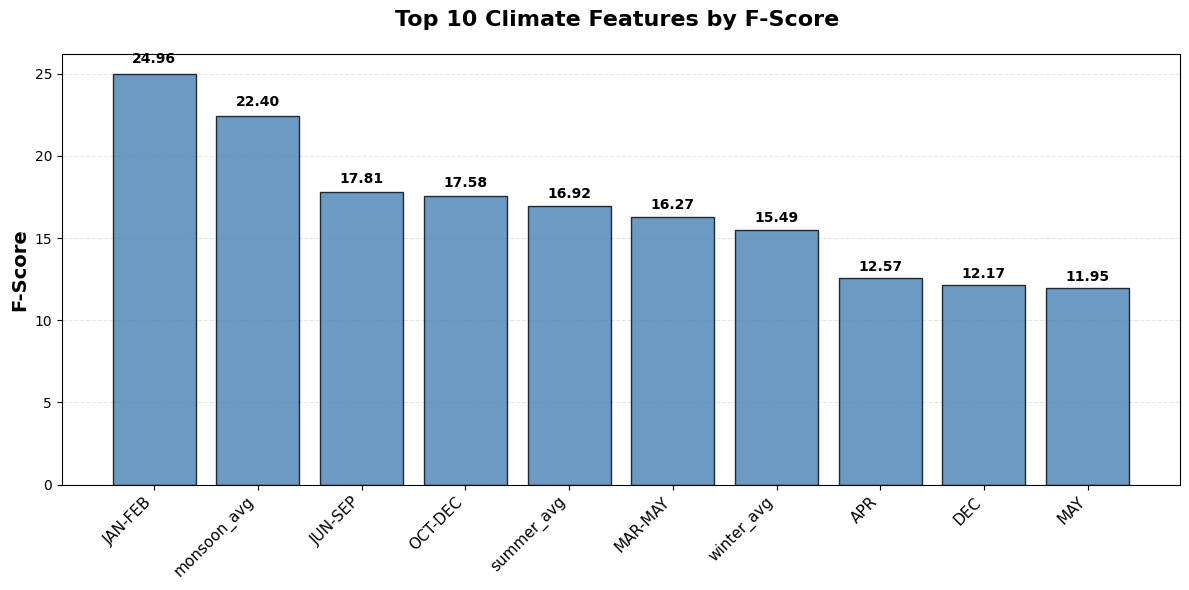


=== Detailed F-Score Analysis ===
JAN-FEB                  : F-Score = 24.9589
monsoon_avg              : F-Score = 22.4022
JUN-SEP                  : F-Score = 17.8070
OCT-DEC                  : F-Score = 17.5791
summer_avg               : F-Score = 16.9234
MAR-MAY                  : F-Score = 16.2678
winter_avg               : F-Score = 15.4855
APR                      : F-Score = 12.5709
DEC                      : F-Score = 12.1651
MAY                      : F-Score = 11.9527


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression
from sklearn.decomposition import PCA

# ===================== F-SCORE ANALYSIS ON CLIMATE DATA ONLY =====================

# Assuming 'climate_reduced' is your climate dataset
print("=== F-Score Analysis on Climate Data Only ===")


# Copy climate data
climate_data = climate_reduced.copy()
climate_features = climate_data.drop(
    columns=['Year', 'ANNUAL'],
    errors='ignore'
)


# Keep only numeric columns
numeric_cols = climate_features.select_dtypes(include=[np.number]).columns
climate_features = climate_features[numeric_cols]

print(f"Climate data shape: {climate_features.shape}")
print(f"Features: {climate_features.columns.tolist()}")

# Handle missing values
climate_features = climate_features.fillna(climate_features.mean())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(climate_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=climate_features.columns)

# ===================== F-SCORE USING PCA COMPONENTS =====================

# Use PCA to create pseudo-targets
n_components = min(5, X_scaled.shape[1])  # Use 5 PCA components
pca = PCA(n_components=n_components)
pca_scores = pca.fit_transform(X_scaled)

# Calculate F-scores for each feature against each PCA component
all_f_scores = []

for i in range(n_components):
    # F-test between features and PCA component
    f_scores, p_values = f_regression(X_scaled, pca_scores[:, i])
    all_f_scores.append(f_scores)

# Calculate average F-score across all PCA components
avg_f_scores = np.mean(all_f_scores, axis=0)

# Create final F-score DataFrame
f_score_df = pd.DataFrame({
    'Feature': climate_features.columns,
    'F_Score': avg_f_scores
}).sort_values('F_Score', ascending=False)

print("\n=== F-Score Results ===")
print(f_score_df.head(10))

# ===================== F-SCORE BAR CHART =====================

# Plot F-scores
plt.figure(figsize=(12, 6))
bars = plt.bar(f_score_df['Feature'].head(10), f_score_df['F_Score'].head(10),
               color='steelblue', alpha=0.8, edgecolor='black')

# Customize the plot
# plt.xlabel("Climate Features", fontsize=14, fontweight='bold')
plt.ylabel("F-Score", fontsize=14, fontweight='bold')
plt.title("Top 10 Climate Features by F-Score ",
          fontsize=16, fontweight='bold', pad=20)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add grid
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)

# Adjust layout
plt.tight_layout()
plt.show()

# Print feature details
print("\n=== Detailed F-Score Analysis ===")
for i, row in f_score_df.head(10).iterrows():
    print(f"{row['Feature']:25s}: F-Score = {row['F_Score']:.4f}")

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== 1. LOAD AND PREPARE DATA =====================

# F-score selected features (from your output)
fscore_selected_features = ['JAN-FEB', 'monsoon_avg', 'JUN-SEP', 'OCT-DEC', 'summer_avg', 'MAR-MAY', 'winter_avg','APR', 'DEC', 'MAY']
print(f"F-score selected features: {fscore_selected_features}")

# Load climate data with selected features
# climate_fscore = climate_df_clean[['Year'] + fscore_selected_features].copy()

climate_fscore = climate_df_clean[['Year'] + fscore_selected_features].copy()


print("\nClimate data with F-score selected features:")
print(climate_fscore.head())
print(f"Shape: {climate_fscore.shape}")

# Load crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Element', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha' ]].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

print("\nCrop data:")
print(crop_data_clean.head())
print(f"Shape: {crop_data_clean.shape}")

# ===================== 2. MERGE CROP DATA WITH F-SCORE FEATURES =====================

# Merge crop data with F-score selected climate features
merged_fscore_data = pd.merge(
    crop_data_clean,
    climate_fscore,
    on='Year',
    how='inner'
)

print("\nMerged dataset (crop + F-score selected features):")
print(merged_fscore_data.head())
print(f"Shape: {merged_fscore_data.shape}")
print(f"Columns: {merged_fscore_data.columns.tolist()}")

# ===================== 3. SAVE MERGED DATASET =====================

# Save the merged dataset
merged_fscore_data.to_csv('crop_fscore_merged_data.csv', index=False)
print("\n✅ Merged dataset saved to 'crop_fscore_merged_data.csv'")





F-score selected features: ['JAN-FEB', 'monsoon_avg', 'JUN-SEP', 'OCT-DEC', 'summer_avg', 'MAR-MAY', 'winter_avg', 'APR', 'DEC', 'MAY']

Climate data with F-score selected features:
   Year  JAN-FEB  monsoon_avg  JUN-SEP  OCT-DEC  summer_avg  MAR-MAY  \
0  1961    18.98      263.000    27.06    21.17   44.033333    26.11   
1  1962    18.91      226.650    27.14    21.47   43.466667    25.91   
2  1963    19.07      227.050    27.21    22.04   51.066667    25.57   
3  1964    18.83      249.250    26.90    21.58   37.033333    26.38   
4  1965    19.22      177.125    27.08    22.10   41.500000    25.24   

   winter_avg   APR   DEC   MAY  
0   23.766667  28.5  10.4  77.6  
1   21.366667  43.6  29.9  70.8  
2   10.700000  50.6  15.5  60.9  
3   15.333333  40.0  13.3  52.1  
4   20.700000  45.1  22.2  52.7  
Shape: (58, 11)

Crop data:
    Year    Item Element  Value crop_type  Nitrogen (N) kg/ha  \
58  1965  Apples   Yield  41573    apples               46.33   
59  1966  Apples   Yiel

In [26]:
# ===================== 4. EXPLORE MERGED DATA =====================

print("\n" + "="*60)
print("EXPLORATORY ANALYSIS OF MERGED DATA")
print("="*60)

# Summary statistics
print("\nBasic statistics of merged data:")
print(merged_fscore_data.describe())

# Check for missing values
print("\nMissing values in merged dataset:")
print(merged_fscore_data.isnull().sum())

# Summary by crop
print("\nCrop types in dataset:")
print(merged_fscore_data.groupby('crop_type').agg({
    'Value': ['count', 'mean', 'std', 'min', 'max'],
    'Year': ['min', 'max']
}))



EXPLORATORY ANALYSIS OF MERGED DATA

Basic statistics of merged data:
             Year          Value  Nitrogen (N) kg/ha  Phosphorus (P) kg/ha  \
count  2646.00000    2646.000000         2646.000000           2646.000000   
mean   1991.50000   79671.286092          107.684172             45.545741   
std      15.58873  101513.079735           40.282624             20.141017   
min    1965.00000     382.000000           40.080000             10.070000   
25%    1978.00000   10210.500000           73.622500             27.720000   
50%    1991.50000   52940.000000          105.200000             46.260000   
75%    2005.00000  109048.000000          142.810000             62.630000   
max    2018.00000  765328.000000          179.830000             79.920000   

       Potassium (K) kg/ha      JAN-FEB  monsoon_avg      JUN-SEP  \
count          2646.000000  2646.000000  2646.000000  2646.000000   
mean             54.654376    19.625185   216.730556    27.401481   
std              25

##Cluster analyses

In [27]:
merged_data

,Year,Item,Element,Value,crop_type,Nitrogen (N) kg/ha,Phosphorus (P) kg/ha,Potassium (K) kg/ha,JAN,FEB,...,OCT,NOV,DEC,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC,winter_avg,summer_avg,monsoon_avg
0,1965,Apples,Yield,41573,apples,46.33,50.38,45.03,11.8,28.1,...,34.0,18.2,22.2,19.22,25.24,27.08,22.10,20.700000,41.500000,177.125
1,1966,Apples,Yield,41558,apples,85.55,44.48,10.98,13.1,25.4,...,56.1,51.0,16.7,19.93,26.07,27.17,21.83,18.400000,36.033333,196.925
2,1967,Apples,Yield,41543,apples,94.41,23.67,91.48,11.1,14.2,...,40.6,12.1,56.1,19.44,25.55,27.19,21.68,27.133333,45.200000,221.050
3,1968,Apples,Yield,41509,apples,77.99,60.57,18.22,29.4,19.8,...,67.1,21.8,12.6,18.25,25.62,27.22,21.69,20.600000,35.600000,200.450
4,1969,Apples,Yield,41475,apples,156.02,29.65,38.74,12.7,14.5,...,55.0,35.8,12.7,19.18,26.39,27.35,22.20,13.300000,41.066667,223.525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,2014,Wheat,Yield,28395,wheat,116.25,12.75,78.44,19.2,27.4,...,60.2,14.4,10.7,19.58,26.24,27.88,22.47,19.100000,43.733333,195.525
2642,2015,Wheat,Yield,29886,wheat,50.90,78.41,70.88,17.9,25.6,...,73.1,29.4,19.0,20.12,26.29,27.73,22.99,20.833333,48.533333,219.625
2643,2016,Wheat,Yield,31775,wheat,173.76,26.96,37.09,17.6,26.2,...,76.0,29.2,19.7,22.25,28.86,28.44,24.20,21.166667,47.833333,221.675
2644,2017,Wheat,Yield,31538,wheat,74.57,56.43,26.56,18.2,26.6,...,78.1,28.5,19.3,21.84,28.41,28.50,24.21,21.366667,47.533333,224.425


In [28]:
feature_cols

['JAN',
 'FEB',
 'MAR',
 'APR',
 'MAY',
 'JUN',
 'JUL',
 'AUG',
 'SEP',
 'OCT',
 'NOV',
 'DEC',
 'JAN-FEB',
 'MAR-MAY',
 'JUN-SEP',
 'OCT-DEC',
 'winter_avg',
 'summer_avg',
 'monsoon_avg']

In [29]:
# ===================== 1. LOAD MERGED DATASET =====================

# Load the merged dataset (crop + correlation features)
merged_data = pd.read_csv('crop_fscore_merged_data.csv')

print("="*60)
print("LOADED MERGED DATASET")
print("="*60)
print(f"Dataset shape: {merged_data.shape}")
print(f"Columns: {merged_data.columns.tolist()}")
print("\nFirst 5 rows:")
# print(merged_data.head())

# ===================== 2. PREPARE DATA FOR CLUSTERING =====================

# Select features for clustering (F-score selected features)
# fscore_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
fscore_features = ['JAN-FEB', 'monsoon_avg', 'JUN-SEP', 'OCT-DEC', 'summer_avg', 'MAR-MAY', 'winter_avg','APR', 'DEC', 'MAY']
print(f"\nFeatures used for clustering: {fscore_features}")

# Extract feature matrix
X = merged_data[fscore_features].copy()

# Handle missing values
X = X.fillna(X.mean())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=fscore_features)

print(f"\nFeature matrix shape: {X_scaled_df.shape}")
print("Feature statistics after scaling:")
print(X_scaled_df.describe())

LOADED MERGED DATASET
Dataset shape: (2646, 18)
Columns: ['Year', 'Item', 'Element', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha', 'JAN-FEB', 'monsoon_avg', 'JUN-SEP', 'OCT-DEC', 'summer_avg', 'MAR-MAY', 'winter_avg', 'APR', 'DEC', 'MAY']

First 5 rows:

Features used for clustering: ['JAN-FEB', 'monsoon_avg', 'JUN-SEP', 'OCT-DEC', 'summer_avg', 'MAR-MAY', 'winter_avg', 'APR', 'DEC', 'MAY']

Feature matrix shape: (2646, 10)
Feature statistics after scaling:
            JAN-FEB   monsoon_avg       JUN-SEP       OCT-DEC    summer_avg  \
count  2.646000e+03  2.646000e+03  2.646000e+03  2.646000e+03  2.646000e+03   
mean   6.867774e-16  1.472241e-15  6.486455e-15 -1.902568e-15 -8.678705e-16   
std    1.000189e+00  1.000189e+00  1.000189e+00  1.000189e+00  1.000189e+00   
min   -1.780266e+00 -2.396129e+00 -2.217119e+00 -1.607247e+00 -1.837028e+00   
25%   -6.281035e-01 -7.889425e-01 -6.172380e-01 -6.389349e-01 -7.005203e-01   
50%   -9.733207e-02


DETERMINING OPTIMAL NUMBER OF CLUSTERS


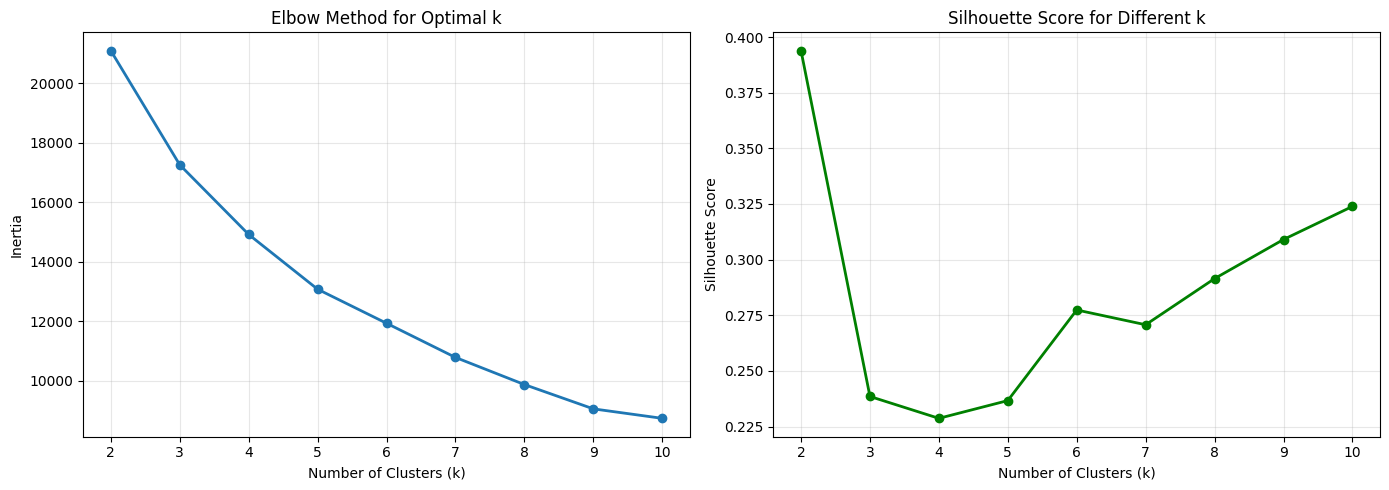

In [30]:
# ===================== 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD) =====================

print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

# Elbow method
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='o', color='green', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [31]:
# # ===================== 6. METHOD 3: HIERARCHICAL CLUSTERING =====================

# print("\n" + "="*60)
# print("METHOD 3: HIERARCHICAL CLUSTERING")
# print("="*60)

# # Try different linkage methods and number of clusters
# linkage_methods = ['ward', 'complete', 'average', 'single']
# best_hierarchical_score = -1
# best_hierarchical_params = None
# best_hierarchical_labels = None

# print("Testing Hierarchical Clustering with different parameters:")
# for method in linkage_methods:
#     for n_clusters in range(2, 8):
#         hierarchical = AgglomerativeClustering(
#             n_clusters=n_clusters,
#             linkage=method
#         )
#         labels = hierarchical.fit_predict(X_scaled)

#         try:
#             score = silhouette_score(X_scaled, labels)
#             if score > best_hierarchical_score:
#                 best_hierarchical_score = score
#                 best_hierarchical_params = (method, n_clusters)
#                 best_hierarchical_labels = labels
#             print(f"  method={method}, n_clusters={n_clusters}: silhouette={score:.4f}")
#         except:
#             print(f"  method={method}, n_clusters={n_clusters}: Cannot compute silhouette")

# if best_hierarchical_labels is not None:
#     merged_data['Hierarchical_Cluster'] = best_hierarchical_labels
#     print(f"\nBest Hierarchical parameters: method={best_hierarchical_params[0]}, n_clusters={best_hierarchical_params[1]}")
#     print(f"Best Silhouette Score: {best_hierarchical_score:.4f}")
#     print(f"Cluster sizes:")
#     print(pd.Series(best_hierarchical_labels).value_counts().sort_index())
# else:
#     # Use default hierarchical
#     hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
#     hierarchical_labels = hierarchical.fit_predict(X_scaled)
#     merged_data['Hierarchical_Cluster'] = hierarchical_labels
#     print("Using default hierarchical (n_clusters=3, linkage='ward')")



METHOD 3: HIERARCHICAL CLUSTERING
Testing Hierarchical Clustering with different parameters:
  method=ward, n_clusters=2: silhouette=0.4325
  method=ward, n_clusters=3: silhouette=0.2436
  method=ward, n_clusters=4: silhouette=0.2370
  method=ward, n_clusters=5: silhouette=0.2413
  method=ward, n_clusters=6: silhouette=0.2468
  method=ward, n_clusters=7: silhouette=0.2551
  method=complete, n_clusters=2: silhouette=0.1808
  method=complete, n_clusters=3: silhouette=0.1852
  method=complete, n_clusters=4: silhouette=0.2111
  method=complete, n_clusters=5: silhouette=0.2179
  method=complete, n_clusters=6: silhouette=0.2203
  method=complete, n_clusters=7: silhouette=0.2321
  method=average, n_clusters=2: silhouette=0.4273
  method=average, n_clusters=3: silhouette=0.4152
  method=average, n_clusters=4: silhouette=0.3375
  method=average, n_clusters=5: silhouette=0.2963
  method=average, n_clusters=6: silhouette=0.2754
  method=average, n_clusters=7: silhouette=0.2756
  method=single, n


HIERARCHICAL CLUSTERING DENDROGRAM


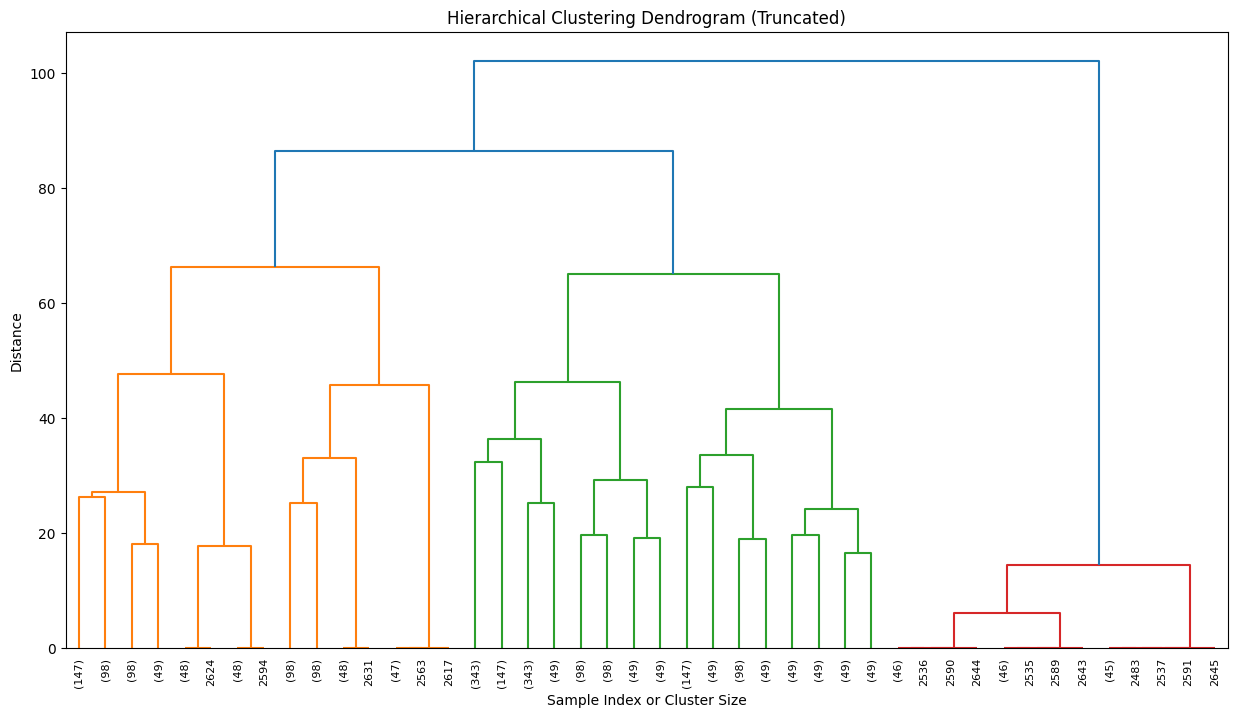

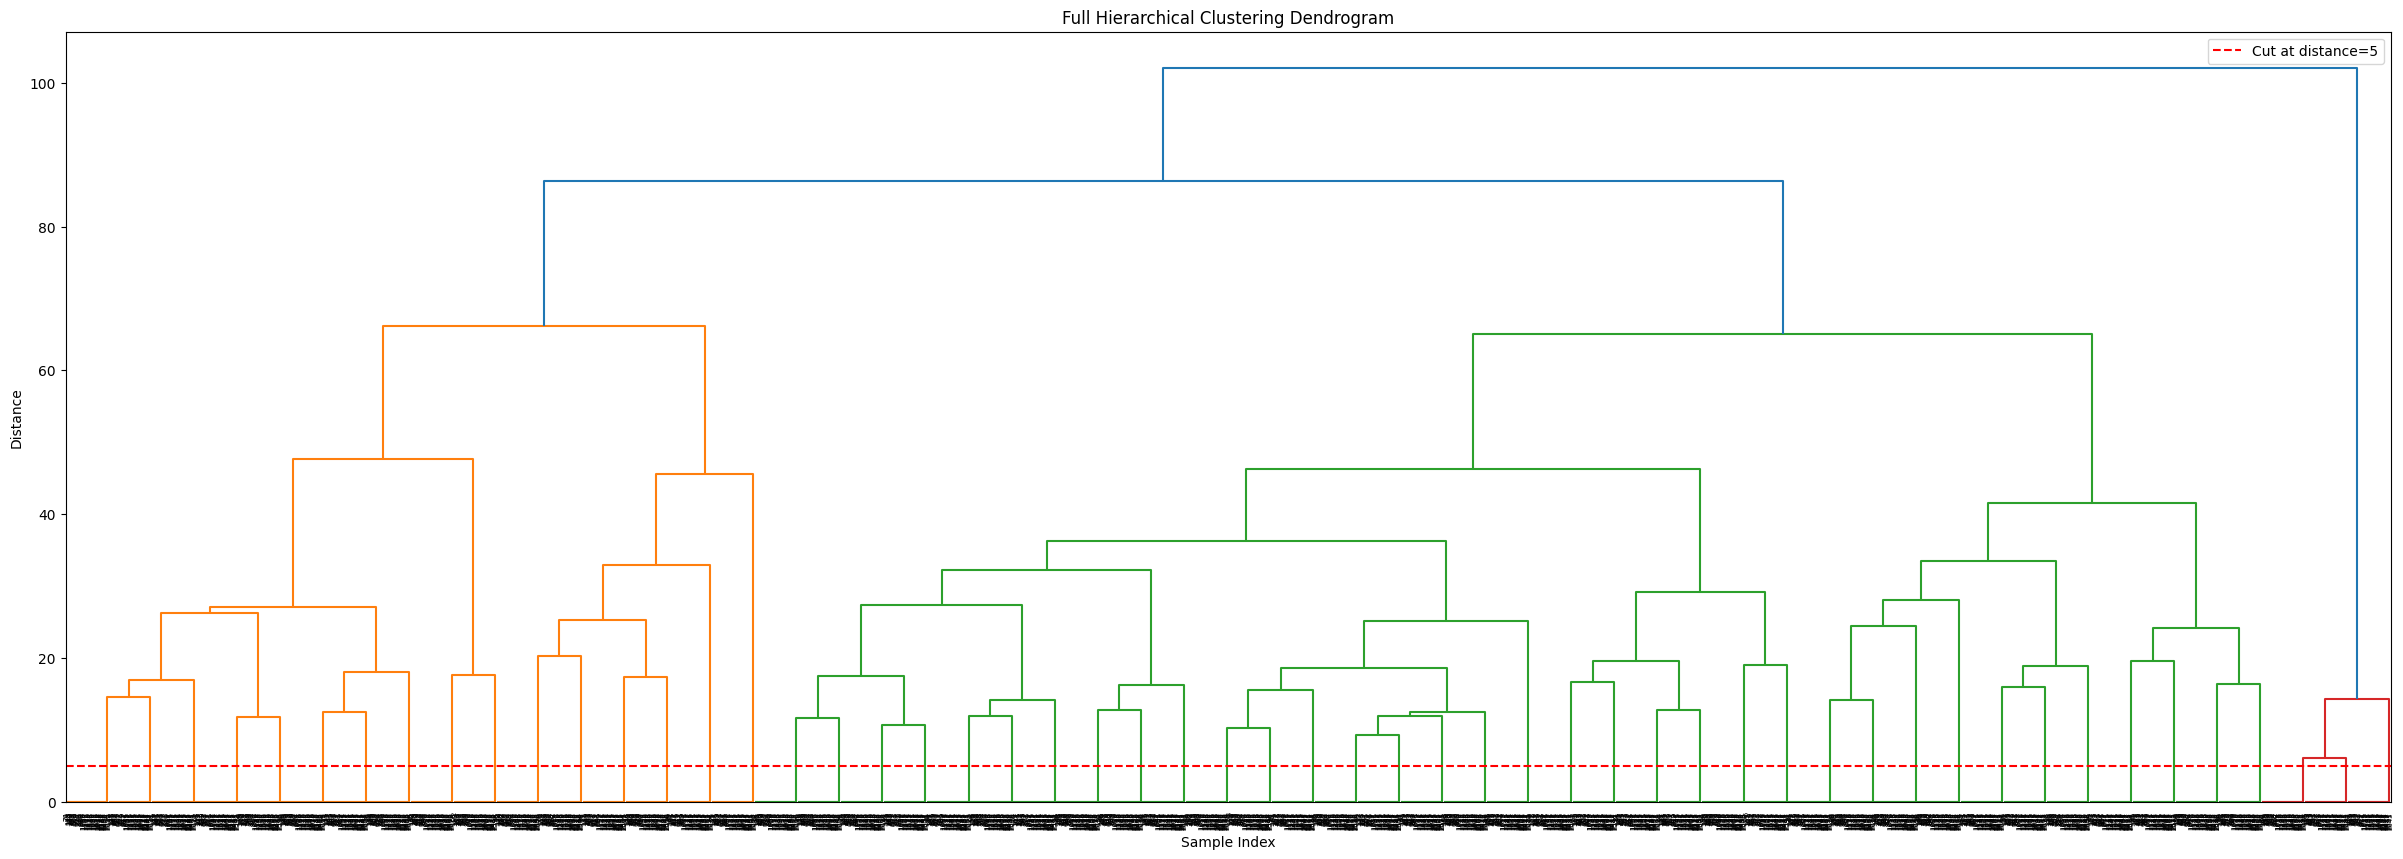

In [32]:
# ===================== 7. DENDROGRAM FOR HIERARCHICAL CLUSTERING =====================

print("\n" + "="*60)
print("HIERARCHICAL CLUSTERING DENDROGRAM")
print("="*60)

# Create linkage matrix
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='level',
           p=5)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

# Full dendrogram
plt.figure(figsize=(30, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Full Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=5, color='r', linestyle='--', label='Cut at distance=5')
plt.legend()
plt.show()

#Clustering

In [33]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

In [34]:
# ===================== 4. METHOD 1: K-MEANS CLUSTERING =====================

print("\n" + "="*60)
print("METHOD 1: K-MEANS CLUSTERING")
print("="*60)

# Apply K-Means with optimal k
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original data
merged_data['KMeans_Cluster'] = kmeans_labels

# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_davies = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"K-Means Evaluation Metrics:")
print(f"  - Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  - Calinski-Harabasz Score: {kmeans_calinski:.4f}")
print(f"  - Davies-Bouldin Score: {kmeans_davies:.4f}")
print(f"\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

# Cluster centers
print("\nCluster Centers (scaled features):")
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=fscore_features
)
print(cluster_centers)


METHOD 1: K-MEANS CLUSTERING
K-Means Evaluation Metrics:
  - Silhouette Score: 0.2385
  - Calinski-Harabasz Score: 705.1360
  - Davies-Bouldin Score: 1.5672

Cluster sizes:
0    1470
1     343
2     833
Name: count, dtype: int64

Cluster Centers (scaled features):
    JAN-FEB  monsoon_avg   JUN-SEP   OCT-DEC  summer_avg   MAR-MAY  \
0 -0.212117    -0.121852 -0.143495 -0.135526   -0.604147 -0.081753   
1  1.835268     0.354428  1.565457  1.863144    0.540603  1.683914   
2 -0.381375     0.069092 -0.391372 -0.528014    0.843541 -0.549106   

   winter_avg       APR       DEC       MAY  
0   -0.369557 -0.568732 -0.435820 -0.340406  
1    0.181218  0.060287  0.137856  0.661935  
2    0.577540  0.978820  0.712330  0.328155  


In [35]:
merged_data=merged_data.drop(columns=['Hierarchical_Cluster'])

In [36]:
# ===================== 11. SAVE CLUSTERED DATA =====================

# Save the data with cluster labels
merged_data.to_csv('crop_fscore_clustered_data.csv', index=False)
print("\n✅ Clustered data saved to 'crop_fscore_clustered_data.csv'")



✅ Clustered data saved to 'crop_fscore_clustered_data.csv'


In [37]:
!pip install catboost

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# ===================== 1. LOAD CLUSTERED DATA =====================

# Load the clustered data
merged_data = pd.read_csv('crop_fscore_clustered_data.csv')

print("="*60)
print("LOADING CLUSTERED DATA")
print("="*60)
print(f"Dataset shape: {merged_data.shape}")
print(f"Cluster distribution:\n{merged_data['KMeans_Cluster'].value_counts()}")

# ===================== 2. PREPARE DATA FOR EACH CLUSTER =====================

# Define F-score features
fscore_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']

# Encode crop type
le = LabelEncoder()
merged_data['crop_type_encoded'] = le.fit_transform(merged_data['crop_type'])

# Add cluster as feature
merged_data['cluster'] = merged_data['KMeans_Cluster']

# Prepare features and target
X = merged_data[fscore_features + ['crop_type_encoded', 'cluster']].copy()
# y = merged_data['Value'].copy()
# y = crop_df[crop_df['Element'] == 'Yield']['Value']
y = merged_data[merged_data['Element'] == 'Yield']['Value']

# Handle missing values
X = X.fillna(X.mean())
y = y.fillna(y.mean())

print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)
print(f"Features: {X.columns.tolist()}")
print(f"Total samples: {len(X)}")

# ===================== 3. SPLIT DATA BY CLUSTER =====================

# Split data for Cluster 0
cluster_0_mask = merged_data['KMeans_Cluster'] == 0
X0 = X[cluster_0_mask]
y0 = y[cluster_0_mask]

# Split data for Cluster 1
cluster_1_mask = merged_data['KMeans_Cluster'] == 1
X1 = X[cluster_1_mask]
y1 = y[cluster_1_mask]

# Split data for Cluster 1
cluster_2_mask = merged_data['KMeans_Cluster'] == 2
X2 = X[cluster_2_mask]
y2 = y[cluster_2_mask]

print("\n" + "="*60)
print("CLUSTER DATA SPLIT")
print("="*60)
print(f"Cluster 0 samples: {len(X0)}")
print(f"Cluster 1 samples: {len(X1)}")
print(f"Cluster 2 samples: {len(X2)}")

# ===================== 4. TRAIN-TEST SPLIT FOR EACH CLUSTER =====================

# Split Cluster 0
X0_train, X0_test, y0_train, y0_test = train_test_split(
    X0, y0, test_size=0.3, random_state=42
)

# Split Cluster 1
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, random_state=42
)

# Split Cluster 2
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

print("\n" + "="*60)
print("TRAIN-TEST SPLIT RESULTS")
print("="*60)
print("\nCluster 0:")
print(f"  Train size: {len(X0_train)} ({len(X0_train)/len(X0)*100:.1f}%)")
print(f"  Test size: {len(X0_test)} ({len(X0_test)/len(X0)*100:.1f}%)")

print("\nCluster 1:")
print(f"  Train size: {len(X1_train)} ({len(X1_train)/len(X1)*100:.1f}%)")
print(f"  Test size: {len(X1_test)} ({len(X1_test)/len(X1)*100:.1f}%)")

print("\nCluster 2:")
print(f"  Train size: {len(X2_train)} ({len(X2_train)/len(X2)*100:.1f}%)")
print(f"  Test size: {len(X2_test)} ({len(X2_test)/len(X2)*100:.1f}%)")

# ===================== 5. SCALE FEATURES =====================

# Scale features for Cluster 0
scaler0 = StandardScaler()
X0_train_scaled = scaler0.fit_transform(X0_train)
X0_test_scaled = scaler0.transform(X0_test)

# Scale features for Cluster 1
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# Scale features for Cluster 2
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print("\nFeature scaling completed!")

# ===================== 6. DEFINE MODELS =====================

models = {
    'CatBoost': CatBoostRegressor(verbose=0, random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

# ===================== 7. TRAIN AND EVALUATE MODELS ON CLUSTER 0 =====================

print("\n" + "="*60)
print("MODEL PERFORMANCE ON CLUSTER 0")
print("="*60)

results_cluster0 = {}

for name, model in models.items():
    # Train
    model.fit(X0_train_scaled, y0_train)

    # Predict
    y0_train_pred = model.predict(X0_train_scaled)
    y0_test_pred = model.predict(X0_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y0_train, y0_train_pred)
    test_r2 = r2_score(y0_test, y0_test_pred)
    train_mae = mean_absolute_error(y0_train, y0_train_pred)
    test_mae = mean_absolute_error(y0_test, y0_test_pred)
    train_mse = mean_squared_error(y0_train, y0_train_pred)
    test_mse = mean_squared_error(y0_test, y0_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    results_cluster0[name] = {
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse
    }

    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Train MAE: {train_mae:.2f}")
    print(f"  Test MAE: {test_mae:.2f}")
    print(f"  Train RMSE: {train_rmse:.2f}")
    print(f"  Test RMSE: {test_rmse:.2f}")

# ===================== 8. TRAIN AND EVALUATE MODELS ON CLUSTER 1 =====================

print("\n" + "="*60)
print("MODEL PERFORMANCE ON CLUSTER 1")
print("="*60)

results_cluster1 = {}

for name, model in models.items():
    # Train
    model.fit(X1_train_scaled, y1_train)

    # Predict
    y1_train_pred = model.predict(X1_train_scaled)
    y1_test_pred = model.predict(X1_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y1_train, y1_train_pred)
    test_r2 = r2_score(y1_test, y1_test_pred)
    train_mae = mean_absolute_error(y1_train, y1_train_pred)
    test_mae = mean_absolute_error(y1_test, y1_test_pred)
    train_mse = mean_squared_error(y1_train, y1_train_pred)
    test_mse = mean_squared_error(y1_test, y1_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    results_cluster1[name] = {
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse
    }

    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Train MAE: {train_mae:.2f}")
    print(f"  Test MAE: {test_mae:.2f}")
    print(f"  Train RMSE: {train_rmse:.2f}")
    print(f"  Test RMSE: {test_rmse:.2f}")

# ===================== 9. TRAIN AND EVALUATE MODELS ON CLUSTER 2 =====================

print("\n" + "="*60)
print("MODEL PERFORMANCE ON CLUSTER 2")
print("="*60)

results_cluster2 = {}

for name, model in models.items():
    # Train
    model.fit(X2_train_scaled, y2_train)

    # Predict
    y2_train_pred = model.predict(X2_train_scaled)
    y2_test_pred = model.predict(X2_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y2_train, y2_train_pred)
    test_r2 = r2_score(y2_test, y2_test_pred)
    train_mae = mean_absolute_error(y2_train, y2_train_pred)
    test_mae = mean_absolute_error(y2_test, y2_test_pred)
    train_mse = mean_squared_error(y2_train, y2_train_pred)
    test_mse = mean_squared_error(y2_test, y2_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    results_cluster2[name] = {
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse
    }

    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Train MAE: {train_mae:.2f}")
    print(f"  Test MAE: {test_mae:.2f}")
    print(f"  Train RMSE: {train_rmse:.2f}")
    print(f"  Test RMSE: {test_rmse:.2f}")

# ===================== 10. COMPARE RESULTS =====================

print("\n" + "="*60)
print("COMPARISON OF MODELS - CLUSTER 0")
print("="*60)

comparison0 = pd.DataFrame(results_cluster0).T
print(comparison0[['Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE']].round(4))

print("\n" + "="*60)
print("COMPARISON OF MODELS - CLUSTER 1")
print("="*60)

comparison1 = pd.DataFrame(results_cluster1).T
print(comparison1[['Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE']].round(4))

print("\n" + "="*60)
print("COMPARISON OF MODELS - CLUSTER 2")
print("="*60)

comparison2 = pd.DataFrame(results_cluster2).T
print(comparison2[['Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE']].round(4))

# ===================== 11. FIND BEST MODEL FOR EACH CLUSTER =====================

print("\n" + "="*60)
print("BEST MODEL FOR EACH CLUSTER")
print("="*60)

# Cluster 0 - Best model by Test R²
best_model0 = comparison0['Test_R2'].idxmax()
best_r2_0 = comparison0.loc[best_model0, 'Test_R2']
best_rmse0 = comparison0.loc[best_model0, 'Test_RMSE']

print(f"\nCluster 0:")
print(f"  Best Model: {best_model0}")
print(f"  Test R²: {best_r2_0:.4f}")
print(f"  Test RMSE: {best_rmse0:.2f}")

# Cluster 1 - Best model by Test R²
best_model1 = comparison1['Test_R2'].idxmax()
best_r2_1 = comparison1.loc[best_model1, 'Test_R2']
best_rmse1 = comparison1.loc[best_model1, 'Test_RMSE']

print(f"\nCluster 1:")
print(f"  Best Model: {best_model1}")
print(f"  Test R²: {best_r2_1:.4f}")
print(f"  Test RMSE: {best_rmse1:.2f}")

# Cluster 2 - Best model by Test R²
best_model2 = comparison2['Test_R2'].idxmax()
best_r2_2 = comparison2.loc[best_model2, 'Test_R2']
best_rmse2 = comparison2.loc[best_model2, 'Test_RMSE']

print(f"\nCluster 2:")
print(f"  Best Model: {best_model2}")
print(f"  Test R²: {best_r2_2:.4f}")
print(f"  Test RMSE: {best_rmse2:.2f}")

# ===================== 12. OVERALL BEST MODEL =====================

# Combine results for both clusters
all_results = {}

for name in models.keys():
    # Average performance across clusters
    avg_test_r2 = (results_cluster0[name]['Test_R2'] + results_cluster1[name]['Test_R2'] + results_cluster2[name]['Test_R2']) / 3
    avg_test_rmse = (results_cluster0[name]['Test_RMSE'] + results_cluster1[name]['Test_RMSE'] + results_cluster2[name]['Test_RMSE']) / 3

    all_results[name] = {
        'Avg_Test_R2': avg_test_r2,
        'Avg_Test_RMSE': avg_test_rmse,
        'Cluster0_R2': results_cluster0[name]['Test_R2'],
        'Cluster1_R2': results_cluster1[name]['Test_R2'],
        'Cluster0_RMSE': results_cluster0[name]['Test_RMSE'],
        'Cluster1_RMSE': results_cluster1[name]['Test_RMSE']
    }

overall_comparison = pd.DataFrame(all_results).T
print("\n" + "="*60)
print("OVERALL MODEL COMPARISON (Average Across Clusters)")
print("="*60)
print(overall_comparison[['Avg_Test_R2', 'Avg_Test_RMSE', 'Cluster0_R2', 'Cluster1_R2']].round(4))

# Overall best model
best_overall = overall_comparison['Avg_Test_R2'].idxmax()
print(f"\n🏆 Overall Best Model: {best_overall}")
print(f"   Average Test R²: {overall_comparison.loc[best_overall, 'Avg_Test_R2']:.4f}")
print(f"   Average Test RMSE: {overall_comparison.loc[best_overall, 'Avg_Test_RMSE']:.2f}")

# ===================== 13. TRAIN FINAL MODEL ON FULL DATA =====================

print("\n" + "="*60)
print("TRAINING BEST MODEL ON FULL DATASET")
print("="*60)

# Get the best model
if best_overall == 'CatBoost':
    final_model = CatBoostRegressor(verbose=0, random_state=42)
elif best_overall == 'XGBoost':
    final_model = XGBRegressor(random_state=42, verbosity=0)
elif best_overall == 'RandomForest':
    final_model = RandomForestRegressor(random_state=42, n_jobs=-1)
elif best_overall == 'LightGBM':
    final_model = LGBMRegressor(random_state=42, verbose=-1)
else:
    final_model = GradientBoostingRegressor(random_state=42)

# Scale all data
scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(X)
y_final = y

# Train on full data
final_model.fit(X_scaled_final, y_final)

print(f"✅ {best_overall} trained on full dataset ({len(X)} samples)")
print(f"   Features used: {X.columns.tolist()}")

print("\n✅ Train-test split and model evaluation completed successfully!")

LOADING CLUSTERED DATA
Dataset shape: (2646, 19)
Cluster distribution:
KMeans_Cluster
0    1470
2     833
1     343
Name: count, dtype: int64


KeyError: "['FEB'] not in index"